### Predicting Entrained Droplet Fraction (e)

- Capstone Project: Simplified EDA + Modeling

- Author: ACW

- Date: 11/01/2025

#### What the paper did  

**Dataset:** 1367 points  

**Inputs (8 variables):**  
1. Superficial liquid velocity (usl)  
2. Superficial gas velocity (usg)  
3. Liquid viscosity (μl)  
4. Gas viscosity (μg)  
5. Liquid density (ρl)  
6. Gas density (ρg)  
7. Surface tension (σ)  
8. Pipe diameter (D)  

**Output:**  
- Entrained droplet fraction (e)  

**Model:**  
- Feedforward ANN with one hidden layer  

**Architecture:**  
- 8–6–1 (8 inputs, 6 hidden neurons, 1 output)  

**Activation:**  
- Sigmoid in hidden layer  

**Training:**  
- MATLAB implementation  
- Levenberg-Marquardt backpropagation (LM)  

**Hyperparameters:**  
- Max epochs = 5000  
- Learning rate = 0.01  
- Early stopping (max validation failures = 20)  
- Mu damping factor (LM algorithm)  

**Performance:**  
- ANN achieved **R² ≈ 0.97**, **RMSE ≈ 0.005**  
- Outperformed: Decision Trees, SVM, Ensemble, Gaussian Process Regression  

**Sensitivity Analysis:**  
- Gas viscosity (μg) was the most significant input


In [1]:
#Imports
import math, os
import random
import numpy as np
import pandas as pd
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.svm import SVR

import torch
import torch.nn as nn
import torch.optim as optim
#GPU setup
print(torch.cuda.is_available())  # If gpu then True
print(torch.cuda.get_device_name(0))  # should say NVIDIA RTX4070

True
NVIDIA GeForce RTX 4070 Laptop GPU


In [2]:
#Load and Inspect Data
#Parameters
DATA_PATH = r"../data/entraineddropletfraction_VerticalFlow.csv"

df = pd.read_csv(DATA_PATH)

In [3]:
# quick peek
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nFirst 5 rows:\n", df.head())

# data quality
print("\nMissing values per column:")
print(df.isna().sum())
# dtypes
print("\nDtypes:\n", df.dtypes)

Shape: (1367, 9)
Columns: ['D', 'Usg', 'UsL', 'rhol', 'rhog', 'st', 'MuL', 'Mug', 'e']

First 5 rows:
         D    Usg  UsL   rhol   rhog    st       MuL       Mug     e
0  0.1016  18.39  0.1  997.0  1.184  0.07  0.000894  0.000019  0.63
1  0.1016  23.66  0.1  997.0  1.184  0.07  0.000894  0.000019  0.61
2  0.1016  28.87  0.1  997.0  1.184  0.07  0.000894  0.000019  0.67
3  0.1016   9.17  0.2  997.0  1.184  0.07  0.000894  0.000019  0.64
4  0.1016  12.08  0.2  997.0  1.184  0.07  0.000894  0.000019  0.63

Missing values per column:
D       0
Usg     0
UsL     0
rhol    0
rhog    0
st      0
MuL     0
Mug     0
e       0
dtype: int64

Dtypes:
 D       float64
Usg     float64
UsL     float64
rhol    float64
rhog    float64
st      float64
MuL     float64
Mug     float64
e       float64
dtype: object


In [4]:
#Basic statistics
# numeric summary
desc = df.describe().T
print("\nDescriptive statistics:\n", desc)

# target stats
TARGET_COL = "e"
if TARGET_COL in df.columns:
    print("\nTarget summary:")
    print(df[TARGET_COL].describe())


Descriptive statistics:
        count        mean         std         min         25%         50%  \
D     1367.0    0.025928    0.028774    0.005000    0.010000    0.014000   
Usg   1367.0   34.694955   24.762077    1.390000   15.969985   25.057082   
UsL   1367.0    0.565533    1.274229    0.005115    0.084000    0.233224   
rhol  1367.0  992.806203  162.352849  710.000000  997.000000  997.000000   
rhog  1367.0   11.119233   15.611366    1.184000    1.380000    2.841600   
st    1367.0    0.056606    0.024444    0.005860    0.070000    0.070000   
MuL   1367.0    0.001204    0.001506    0.000020    0.000894    0.000894   
Mug   1367.0    0.000027    0.000061    0.000010    0.000019    0.000019   
e     1367.0    0.456581    0.288939    0.003000    0.191924    0.430000   

             75%          max  
D       0.031800     0.127000  
Usg    47.719595   116.000000  
UsL     0.550628    11.515033  
rhol  997.000000  1487.004000  
rhog   22.220000    88.046000  
st      0.070000     

#### Exploratory Data Analysis (EDA)

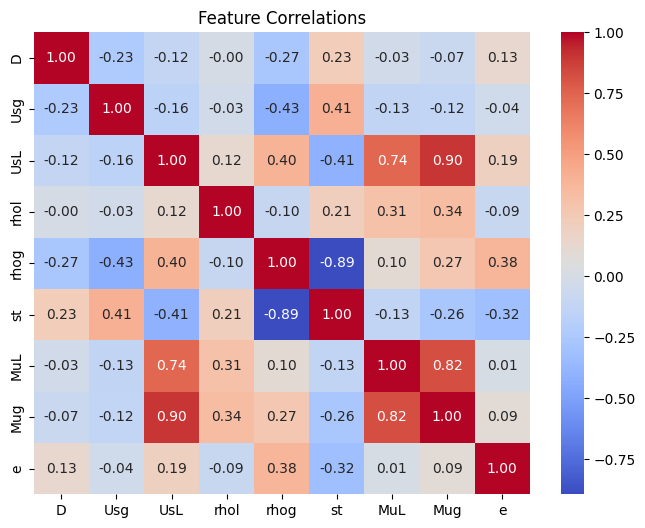

In [5]:
#Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlations")
plt.show()

Correlation matrix shows some multicollinearity between several of the input variables, especially between liquid and gas (MuL-Mug) and surface tension vs. gas density (st-rhog). The target e has moderate linear corelation with individual features, suggesting nonlinear interactions.


Raw features
rhog (gas density) has the strongest raw correlation with entrainment fraction e (~0.38)

st (surface tension) is moderately negative (~-0.32)

Velocities (UsL, Usg) show weaker linear correlation, but we know from the scatterplots that relationships are nonlinear (trees/ANN perform better)

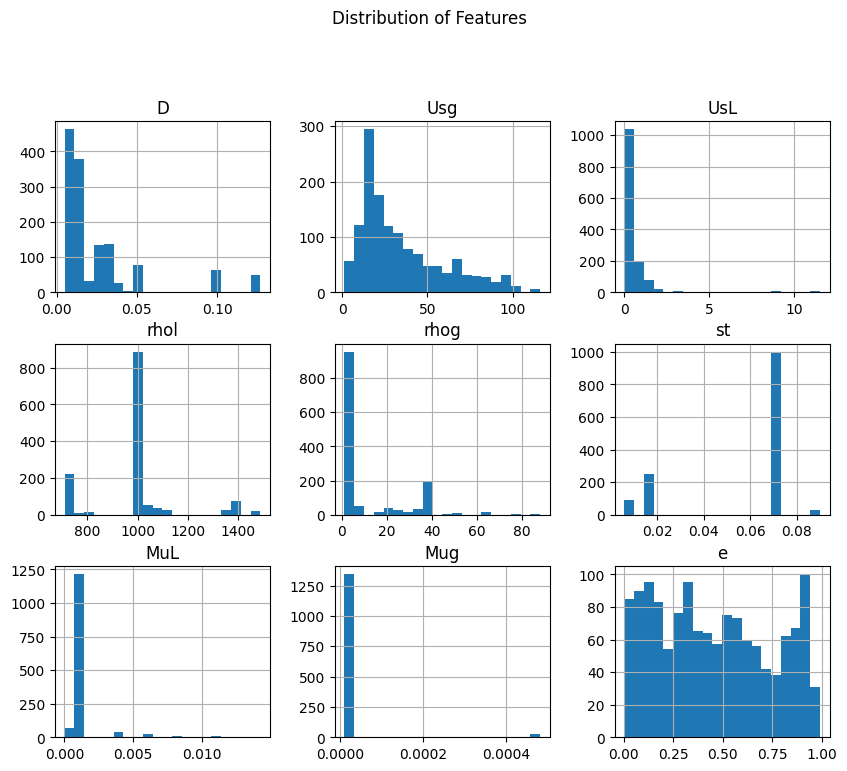

In [6]:
#Histogram
df.hist(bins=20, figsize=(10,8))
plt.suptitle("Distribution of Features", y=1.02)
plt.show()

Most input variables are highly skewed, reflecting the limited range in the dataset. Several features (UsL, MuL, Mug) have clustered values with a few high outliers, indicating potential scale imbalance across conditions.

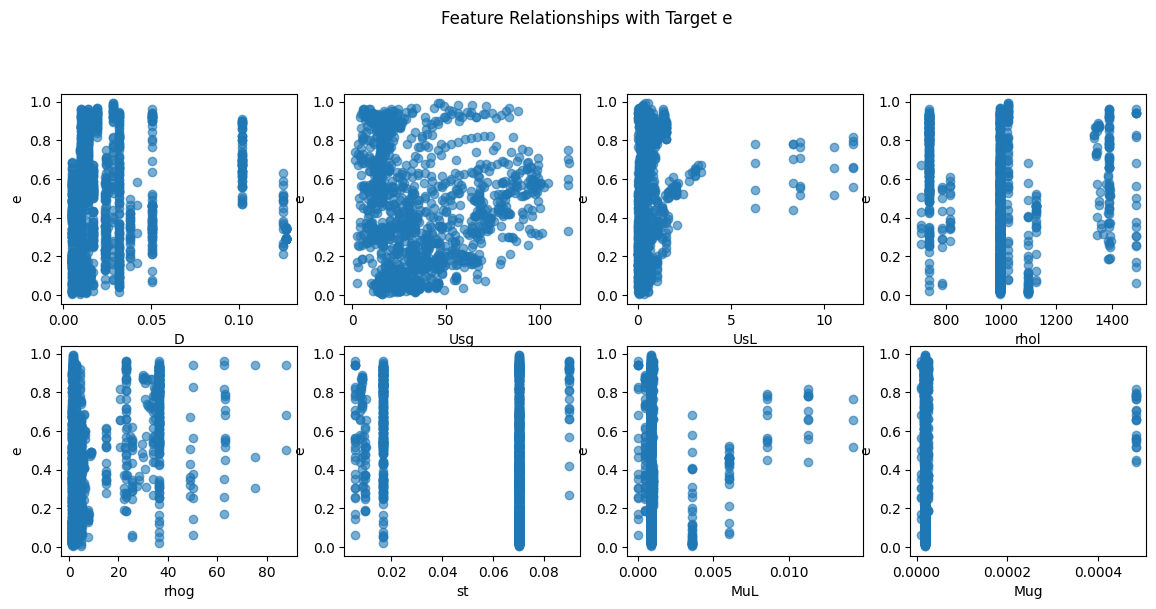

In [7]:
#Scatter Plots of Features vs Target
features = ['D','Usg','UsL','rhol','rhog','st','MuL','Mug']
target = 'e'

fig, axes = plt.subplots(2, 4, figsize=(14,6))
for ax, col in zip(axes.ravel(), features):
    ax.scatter(df[col], df[target], alpha=0.6)
    ax.set_xlabel(col)
    ax.set_ylabel("e")
plt.suptitle("Feature Relationships with Target e", y=1.02)
plt.show()

Scatter plots show that entrained liquid fraction (e) varies nonlinearly with most inputs. Gas and liquid velocities (Usg, UsL) show the clearest positive trends, while surface tension and gas density display inverse relationships, this is consistent with physical expectations.

#### 2nd EDA Pass: Derived Dimensionless Features

Dimensionless Parameters in Fluid Mechanics
Reynolds number: Re
Mach number: Ma
Weber number: We
Strouhal number: St

Used to characterize laminar/turbulent flow, compressible flow, open channel flow, flows with strong surface tension effects, oscillating flows

In [8]:
# Dimensionless Features
df_dim = df.copy()

# Liquid Reynolds number: (rho_l * Usl * D) / mu_l
df_dim["Re_l"] = (df_dim["rhol"] * df_dim["UsL"] * df_dim["D"]) / df_dim["MuL"]

# Gas Reynolds number: (rho_g * Usg * D) / mu_g
df_dim["Re_g"] = (df_dim["rhog"] * df_dim["Usg"] * df_dim["D"]) / df_dim["Mug"]

# Gas Weber number: (rho_g * Usg^2 * D) / sigma
df_dim["We_g"] = (df_dim["rhog"] * (df_dim["Usg"]**2) * df_dim["D"]) / df_dim["st"]

df_dim = df_dim[["Re_l", "Re_g", "We_g", "e"]]
# Summary statistics of dimensionless features
print(df_dim.describe())



                Re_l          Re_g          We_g            e
count    1367.000000  1.367000e+03   1367.000000  1367.000000
mean    11686.562818  1.777693e+05   3236.048620     0.456581
std     29785.054187  1.872082e+05   5311.513731     0.288939
min        45.708333  5.106111e+03      3.320297     0.003000
25%      1249.038031  4.999271e+04    385.645714     0.191924
50%      3785.466038  1.032511e+05   1157.360979     0.430000
75%     10499.999990  2.382580e+05   4089.786744     0.694563
max    494969.999529  1.214286e+06  66661.778144     0.991683


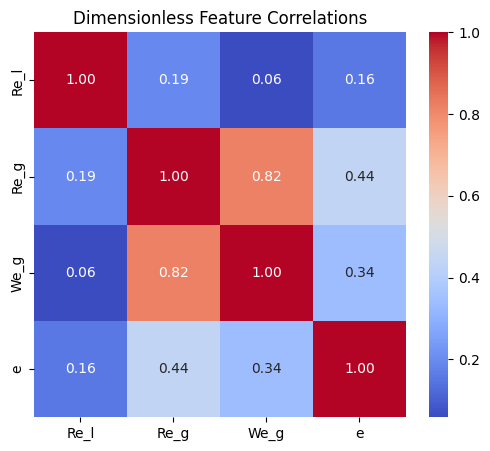

In [9]:
#Correlation Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(df_dim.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Dimensionless Feature Correlations")
plt.show()

Dimensionless Groups
The gas phase Reynolds and Weber numbers are strongly correlated because they both scale with gas velocity and pipe diameter. The liquid Reynolds number is largely independent, this reflects the separate control of liquid phase flow conditions. The entrained fraction (e) is moderately correlated with the Reynolds gas and Weber numbers which indicates that higher gas inertia and interphase fluids are favored for entrainment. Overall, dimensionless groups compress the physics, raw features best for prediction (as the paper showed).

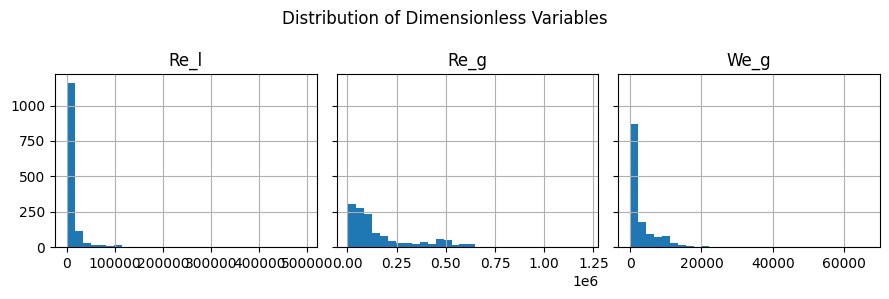

In [10]:
#Histograms of Dimensionless Features
df_dim[["Re_l", "Re_g", "We_g"]].hist(
    bins=30, figsize=(9,3), layout=(1,3), sharey=True
)
plt.suptitle("Distribution of Dimensionless Variables")
plt.tight_layout()
plt.show()

Highly skewed spanning several orders of magnitude. This highlights the broad range of flows captured by the dataset. Keep in mind that the data will probably need to be normalized or scaled before modeling.

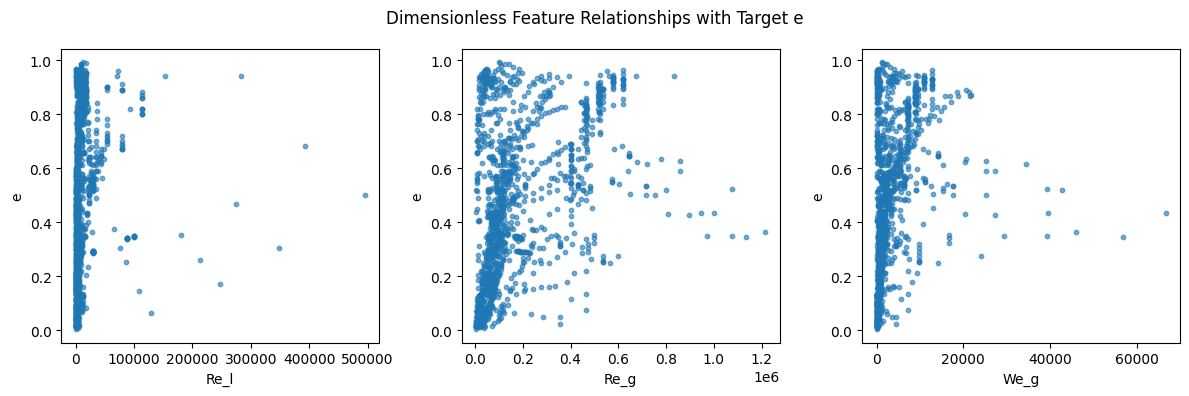

In [11]:
#Scatter Plots of Dimensionless Features vs Target
fig, axes = plt.subplots(1, 3, figsize=(12,4))
for ax, col in zip(axes, ["Re_l", "Re_g", "We_g"]):
    ax.scatter(df_dim[col], df_dim["e"], s=10, alpha=0.6)
    ax.set_xlabel(col)
    ax.set_ylabel("e")
fig.suptitle("Dimensionless Feature Relationships with Target e")
plt.tight_layout()
plt.show()

Entrained liquid fraction increases with both gas Reynolds (Re_g) and Weber (We_g) numbers, supporting the physical expectation that higher inertial forces promote droplet carryover (faster = more entrainment?) Re_l shows weaker or scattered association, implying that liquid-phase inertia alone does not strongly control entrainment in this vertical flow regime.

#### Basic Machine Learning Comparison Raw vs. Dimensionless features

In [16]:
#Prepare Data for Modeling
y      = df["e"].to_numpy()
X_raw  = df.drop(columns=["e"]).to_numpy()
X_dim  = df_dim[["Re_l","Re_g","We_g"]].to_numpy()

#Set seed
SEED = 42
rng = np.random.default_rng(SEED)

In [17]:
#Define Models to Evaluate
models = {
    "Linear Regression": (LinearRegression(), True),
    "Ridge (α=1.0)"    : (Ridge(alpha=1.0, random_state=SEED), True),
    "SVM (poly deg=3)"  : (SVR(kernel="poly", degree=3, C=10, epsilon=0.01), True),
    "Decision Tree d=5" : (DecisionTreeRegressor(max_depth=5, random_state=SEED), False),
    "Random Forest"     : (RandomForestRegressor(n_estimators=200, random_state=SEED), False),
    "Gradient Boosting" : (GradientBoostingRegressor(n_estimators=200, random_state=SEED), False),  # <- no scaling
}

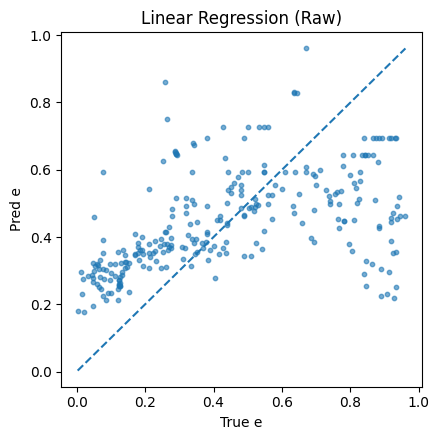

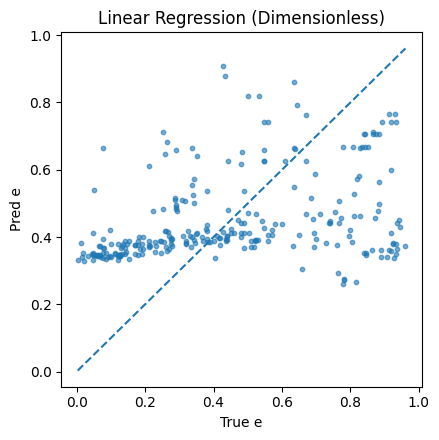

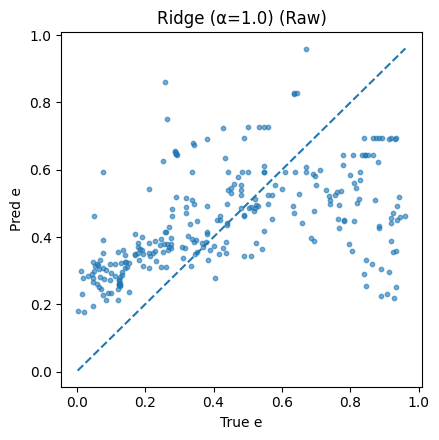

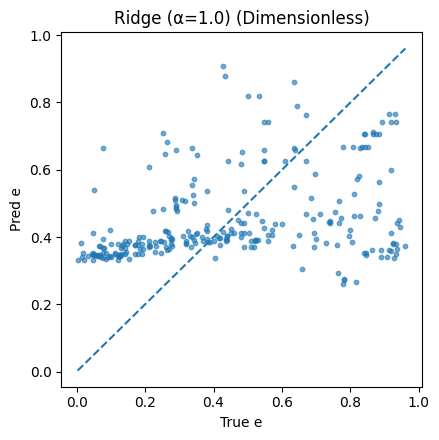

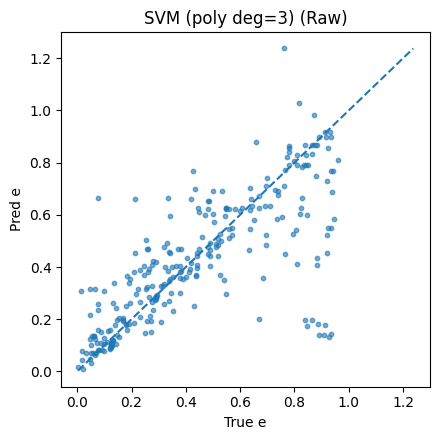

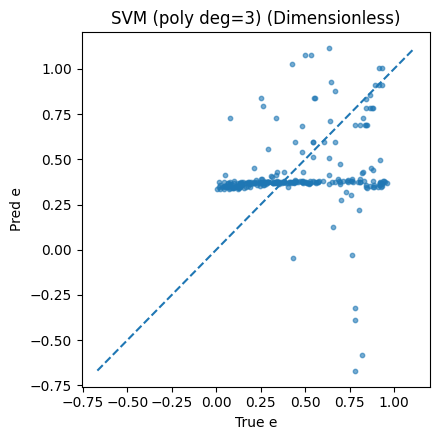

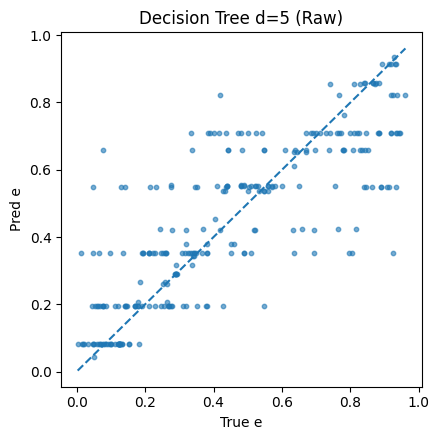

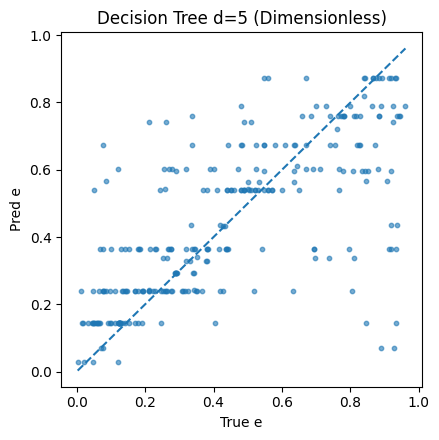

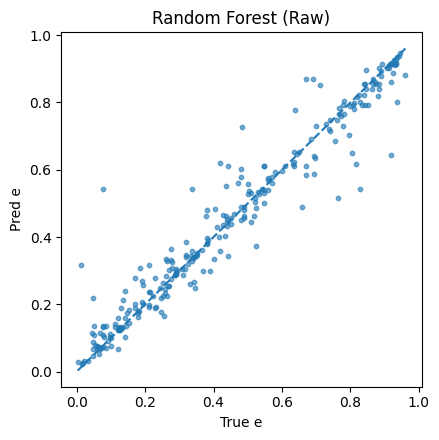

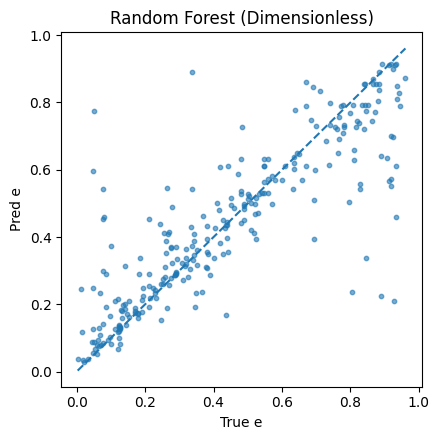

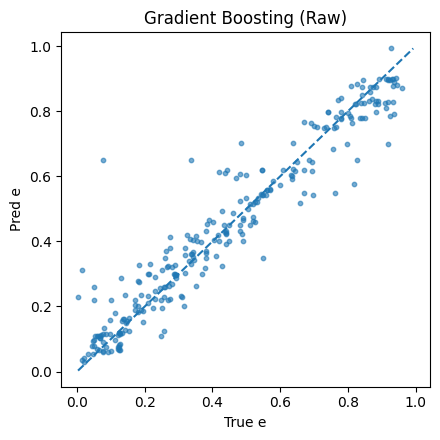

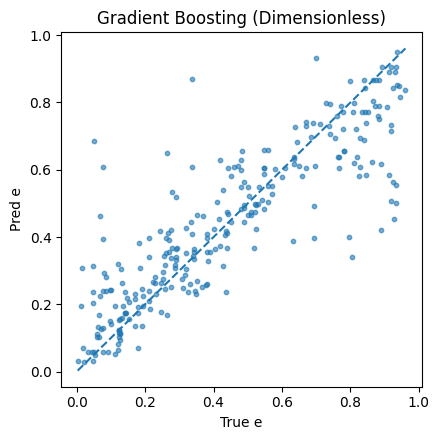

,Method,Feature_Set,RMSE_mean,RMSE_std,R2_mean,R2_std
0,Random Forest,Raw,0.07,0.00,0.94,0.01
1,Gradient Boosting,Raw,0.08,0.00,0.92,0.00
2,Decision Tree d=5,Raw,0.17,0.01,0.67,0.02
3,SVM (poly deg=3),Raw,0.18,0.02,0.59,0.08
4,Ridge (α=1.0),Raw,0.25,0.01,0.27,0.08
5,Linear Regression,Raw,0.25,0.01,0.27,0.08
6,Gradient Boosting,Dimensionless,0.14,0.01,0.76,0.02
7,Random Forest,Dimensionless,0.14,0.02,0.75,0.06
8,Decision Tree d=5,Dimensionless,0.20,0.02,0.53,0.07
9,Ridge (α=1.0),Dimensionless,0.26,0.01,0.19,0.07


In [ ]:
#Helper function to create pipeline with optional scaling
def make_estimator(estimator, needs_scaling: bool):
    return Pipeline([("scaler", StandardScaler()), ("model", estimator)]) if needs_scaling else estimator
#Plotting and Evaluation Functions
def parity_plot(y_true, y_pred, title):
    plt.figure(figsize=(4.5,4.5))
    plt.scatter(y_true, y_pred, s=10, alpha=0.6)
    lo, hi = float(min(y_true.min(), y_pred.min())), float(max(y_true.max(), y_pred.max()))
    plt.plot([lo, hi], [lo, hi], "--")
    plt.xlabel("True e"); plt.ylabel("Pred e"); plt.title(title)
    plt.tight_layout(); plt.show()

def kfold_eval(X, y, estimator, needs_scaling, n_splits=5, seed=SEED):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    r2s, rmses = [], []
    for tr, te in kf.split(X):
        pipe = make_estimator(estimator, needs_scaling)
        pipe.fit(X[tr], y[tr])
        yhat = pipe.predict(X[te])
        mse = mean_squared_error(y[te], yhat)  # compat with older sklearn
        rmse = np.sqrt(mse)
        r2 = r2_score(y[te], yhat)
        rmses.append(rmse); r2s.append(r2)
    return np.mean(rmses), np.std(rmses, ddof=1), np.mean(r2s), np.std(r2s, ddof=1)


#Single Split for fast visuals
Xtr_raw, Xte_raw, ytr, yte = train_test_split(X_raw, y, test_size=0.2, random_state=SEED)
Xtr_dim, Xte_dim, _, _     = train_test_split(X_dim, y, test_size=0.2, random_state=SEED)

for name, (est, need_scale) in models.items():
    # RAW FEATURES
    pipe = make_estimator(est, need_scale)
    pipe.fit(Xtr_raw, ytr)
    yhat = pipe.predict(Xte_raw)
    parity_plot(yte, yhat, f"{name} (Raw)")

    # DIMENSIONLESS FEATURES
    pipe = make_estimator(est, need_scale)
    pipe.fit(Xtr_dim, ytr)
    yhat = pipe.predict(Xte_dim)
    parity_plot(yte, yhat, f"{name} (Dimensionless)")

# 5-fold CV table (Raw vs Dimensionless)
rows = []
for name, (est, need_scale) in models.items():
    rm_mean, rm_std, r2_mean, r2_std = kfold_eval(X_raw, y, est, need_scale)
    rows.append([name, "Raw", rm_mean, rm_std, r2_mean, r2_std])

    rm_mean, rm_std, r2_mean, r2_std = kfold_eval(X_dim, y, est, need_scale)
    rows.append([name, "Dimensionless", rm_mean, rm_std, r2_mean, r2_std])

df_cv = pd.DataFrame(rows, columns=["Method","Feature_Set","RMSE_mean","RMSE_std","R2_mean","R2_std"])
df_cv["Feature_Set"] = pd.Categorical(df_cv["Feature_Set"], ["Raw","Dimensionless"])
df_cv = df_cv.sort_values(["Feature_Set","RMSE_mean"]).reset_index(drop=True)
df_cv[["RMSE_mean","RMSE_std","R2_mean","R2_std"]] = df_cv[["RMSE_mean","RMSE_std","R2_mean","R2_std"]].round(2)
df_cv

Classic Machine Learning Results

Across traditional regression models, tree methods clearly dominate. Random Forest achieved the best overall performance with an average R² ~ 0.94 and RMSE ~ 0.07 on the raw physical features, followed closely by Gradient Boosting (R² ~ 0.92). Simpler models such as linear regression and ridge performed much worse (R² ~ 0.27), confirming that entrainment behavior is highly nonlinear. SVM and Decision Trees gave moderate fits but showed higher variance and sensitivity to feature scaling.

When trained on the dimensionless features, all models preformed poorly Random Forest and Gradient Boosting dropped to R² ~ 0.75, while linear and ridge models fell below 0.2. 

This aligns with the findings from Aliyu et al. (2017): the raw dimensional variables retain more predictive information than the compacted dimensionless groups. The dimensionless form captures physics qualitatively but loses variation and expandability needed for accurate regression.

Discuss physics vs ML

Physics-based features (Re, We) are interpretable but lose accuracy.

ML baselines (RF/GBM) with raw features can capture ~95% of variance.

ANN baseline can then be compared against this strong RF result. (Next notebook)